##### Importing Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Data Collection and Cleaning

In [69]:
df = pd.read_csv("../data/customer_support_tickets.csv")

df.head(2)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN


In [70]:
df.shape

(8469, 17)

8469 tickets are there

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [72]:
df.columns=df.columns.str.lower().str.replace(' ','_')

In [73]:
# as date of purchase columns data type is object we will convert it into datetime datatype

df['date_of_purchase']=pd.to_datetime(df['date_of_purchase'])


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  ticket_status                 8469 non-null   object        
 11  resolution                    

In [75]:
df.describe()

,ticket_id,customer_age,date_of_purchase,customer_satisfaction_rating
count,8469,8469,8469,2769
mean,4235,44,2020-12-30 01:35:13.071201024,3
min,1,18,2020-01-01 00:00:00,1
25%,2118,31,2020-07-02 00:00:00,2
50%,4235,44,2020-12-31 00:00:00,3
75%,6352,57,2021-07-01 00:00:00,4
max,8469,70,2021-12-30 00:00:00,5
std,2445,15,NaN,1


In [76]:
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
customer_age                       0
customer_gender                    0
product_purchased                  0
date_of_purchase                   0
ticket_type                        0
ticket_subject                     0
ticket_description                 0
ticket_status                      0
resolution                      5700
ticket_priority                    0
ticket_channel                     0
first_response_time             2819
time_to_resolution              5700
customer_satisfaction_rating    5700
dtype: int64

 - there are missing values in resolution,first response time,time to resolution,customer satisfaction rating

 - in resolution 5700 missing values it means that no solution given or query or ticket is not resolved yet....

 - The dataset shows a high number of unresolved tickets (5700 missing resolutions), which indicates delays in customer support. This likely impacts response times and customer satisfaction, suggesting the company should prioritize faster ticket resolution and improve support efficiency.

In [77]:
df['resolution'].dtypes=='O'

True

In [78]:
df['first_response_time']=pd.to_datetime(df['first_response_time'])
df['time_to_resolution']=pd.to_datetime(df['time_to_resolution'])

In [79]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['customer_name',
 'customer_email',
 'customer_gender',
 'product_purchased',
 'ticket_type',
 'ticket_subject',
 'ticket_description',
 'ticket_status',
 'resolution',
 'ticket_priority',
 'ticket_channel']

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  ticket_status                 8469 non-null   object        
 11  resolution                    

In [81]:
# unique values in categorical columns

for i in cat_cols:
    print(df[i].unique())
    print("-"*20)
    print()

['Marisa Obrien' 'Jessica Rios' 'Christopher Robbins' ... 'Brandon Walsh'
 'Michelle Kelley' 'Steven Davis MD']
--------------------

['carrollallison@example.com' 'clarkeashley@example.com'
 'gonzalestracy@example.com' ... 'ashley83@example.org'
 'fpowell@example.org' 'lori20@example.net']
--------------------

['Other' 'Female' 'Male']
--------------------

['GoPro Hero' 'LG Smart TV' 'Dell XPS' 'Microsoft Office'
 'Autodesk AutoCAD' 'Microsoft Surface' 'Philips Hue Lights'
 'Fitbit Versa Smartwatch' 'Dyson Vacuum Cleaner' 'Nintendo Switch'
 'Microsoft Xbox Controller' 'Nintendo Switch Pro Controller'
 'Nest Thermostat' 'Sony PlayStation' 'GoPro Action Camera' 'Xbox'
 'LG Washing Machine' 'Canon EOS' 'HP Pavilion' 'Amazon Kindle'
 'Lenovo ThinkPad' 'Fitbit Charge' 'Adobe Photoshop' 'Google Pixel'
 'Amazon Echo' 'PlayStation' 'Samsung Galaxy' 'iPhone' 'LG OLED'
 'Sony Xperia' 'Apple AirPods' 'Sony 4K HDR TV' 'Canon DSLR Camera'
 'Roomba Robot Vacuum' 'Nikon D' 'Bose QuietComfort' 'Sam

In [82]:
df['first_response_time'].dtypes

dtype('<M8[ns]')

In [83]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols

['ticket_id', 'customer_age', 'customer_satisfaction_rating']

In [84]:
df[df['resolution'].isnull()]

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaT,NaT,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaT,NaT,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8462,8463,Shelby Douglas,rhendrix@example.net,49,Female,Samsung Soundbar,2020-10-21,Refund request,Display issue,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Email,2023-06-02 00:36:18,NaT,NaN
8463,8464,Brandon Walsh,michele06@example.net,54,Other,LG Washing Machine,2021-08-29,Billing inquiry,Data loss,There seems to be a glitch in the {product_pur...,Open,NaN,Medium,Email,NaT,NaT,NaN
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaT,NaT,NaN


In [85]:
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
customer_age                       0
customer_gender                    0
product_purchased                  0
date_of_purchase                   0
ticket_type                        0
ticket_subject                     0
ticket_description                 0
ticket_status                      0
resolution                      5700
ticket_priority                    0
ticket_channel                     0
first_response_time             2819
time_to_resolution              5700
customer_satisfaction_rating    5700
dtype: int64

In [86]:
# filling 0 value in resolution column where there are missing values 

# 0->not resolved

df['resolution']=df['resolution'].fillna(0)



In [87]:
cat_cols

['customer_name',
 'customer_email',
 'customer_gender',
 'product_purchased',
 'ticket_type',
 'ticket_subject',
 'ticket_description',
 'ticket_status',
 'resolution',
 'ticket_priority',
 'ticket_channel']

In [88]:
df['ticket_status'].unique()

array(['Pending Customer Response', 'Closed', 'Open'], dtype=object)

In [89]:
df['ticket_status']=df['ticket_status'].str.replace('Pending Customer Response','Pending')

In [90]:
df['ticket_status'].unique()

array(['Pending', 'Closed', 'Open'], dtype=object)

##### EDA

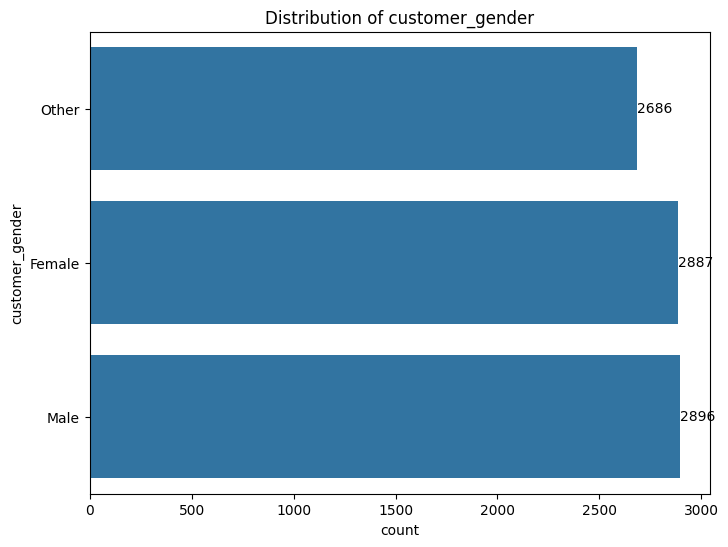

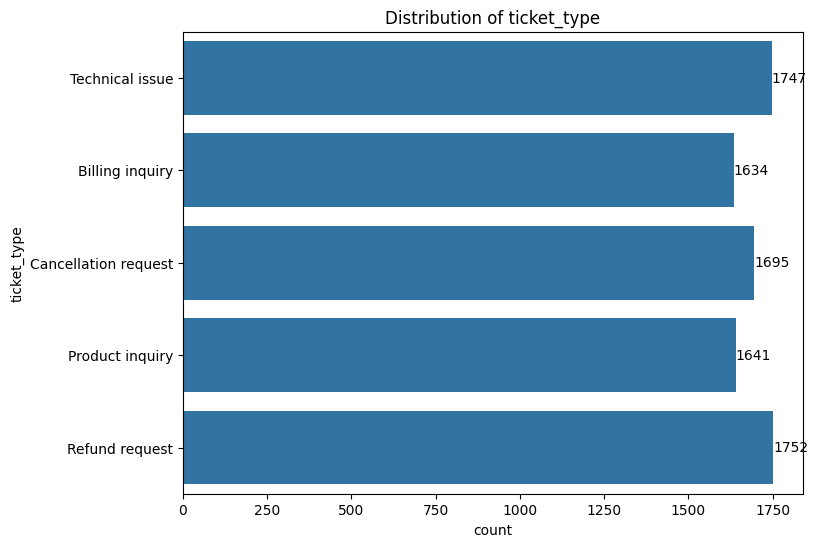

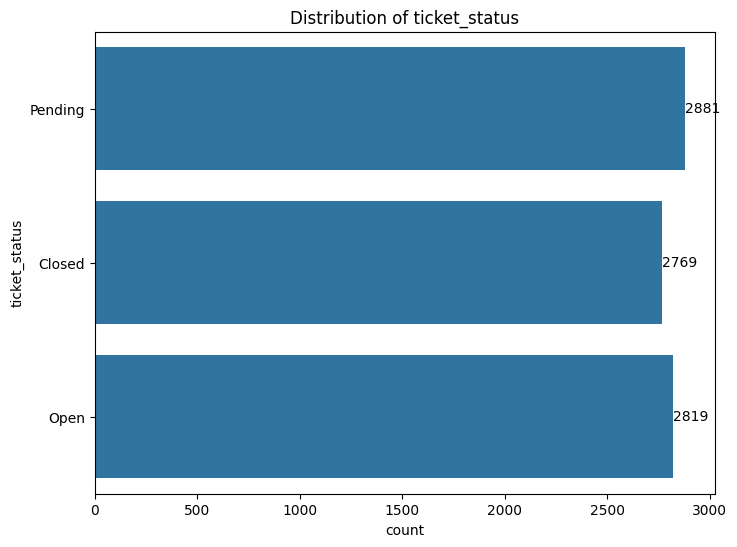

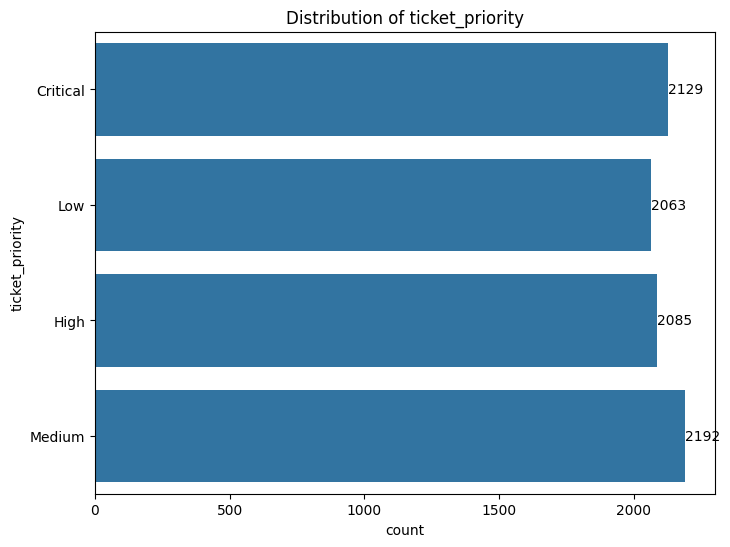

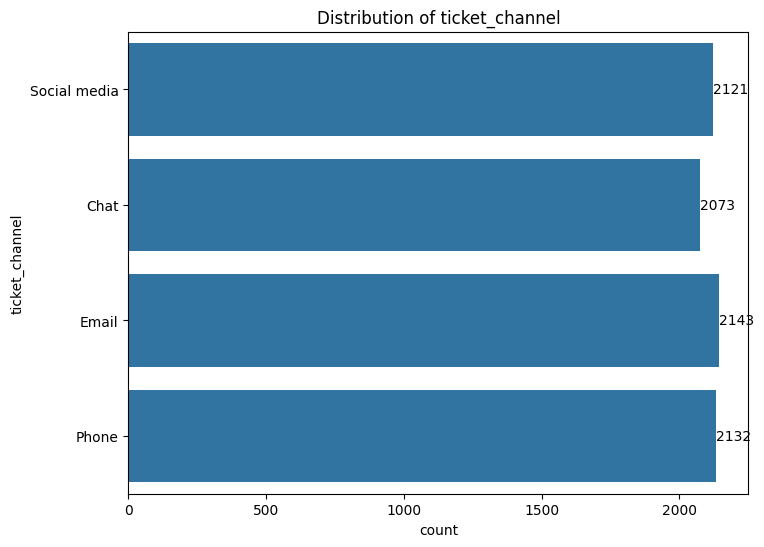

In [91]:
for i in df[['customer_gender','ticket_type','ticket_status','ticket_priority','ticket_channel']]:
    plt.figure(figsize=(8,6))
    ax=sns.countplot(df[i])
    for bar in ax.containers:
        ax.bar_label(bar)
    plt.title(f"Distribution of {i}")
    plt.show()

 - males generate more tickets
 - ticket type is mostly refund request or technical issue
 - pending tickets count is more
 - email channel is used more

#####  1. Which products generate the highest number of support tickets?

product_purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Amazon Echo                       221
Philips Hue Lights                221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  202
Microsoft Office                  200
HP Pavilion                       200
Amazon Kindle                     198
Dyson Vacuum Cleaner              198
Google Nest                       198
Bose SoundLink Speaker          

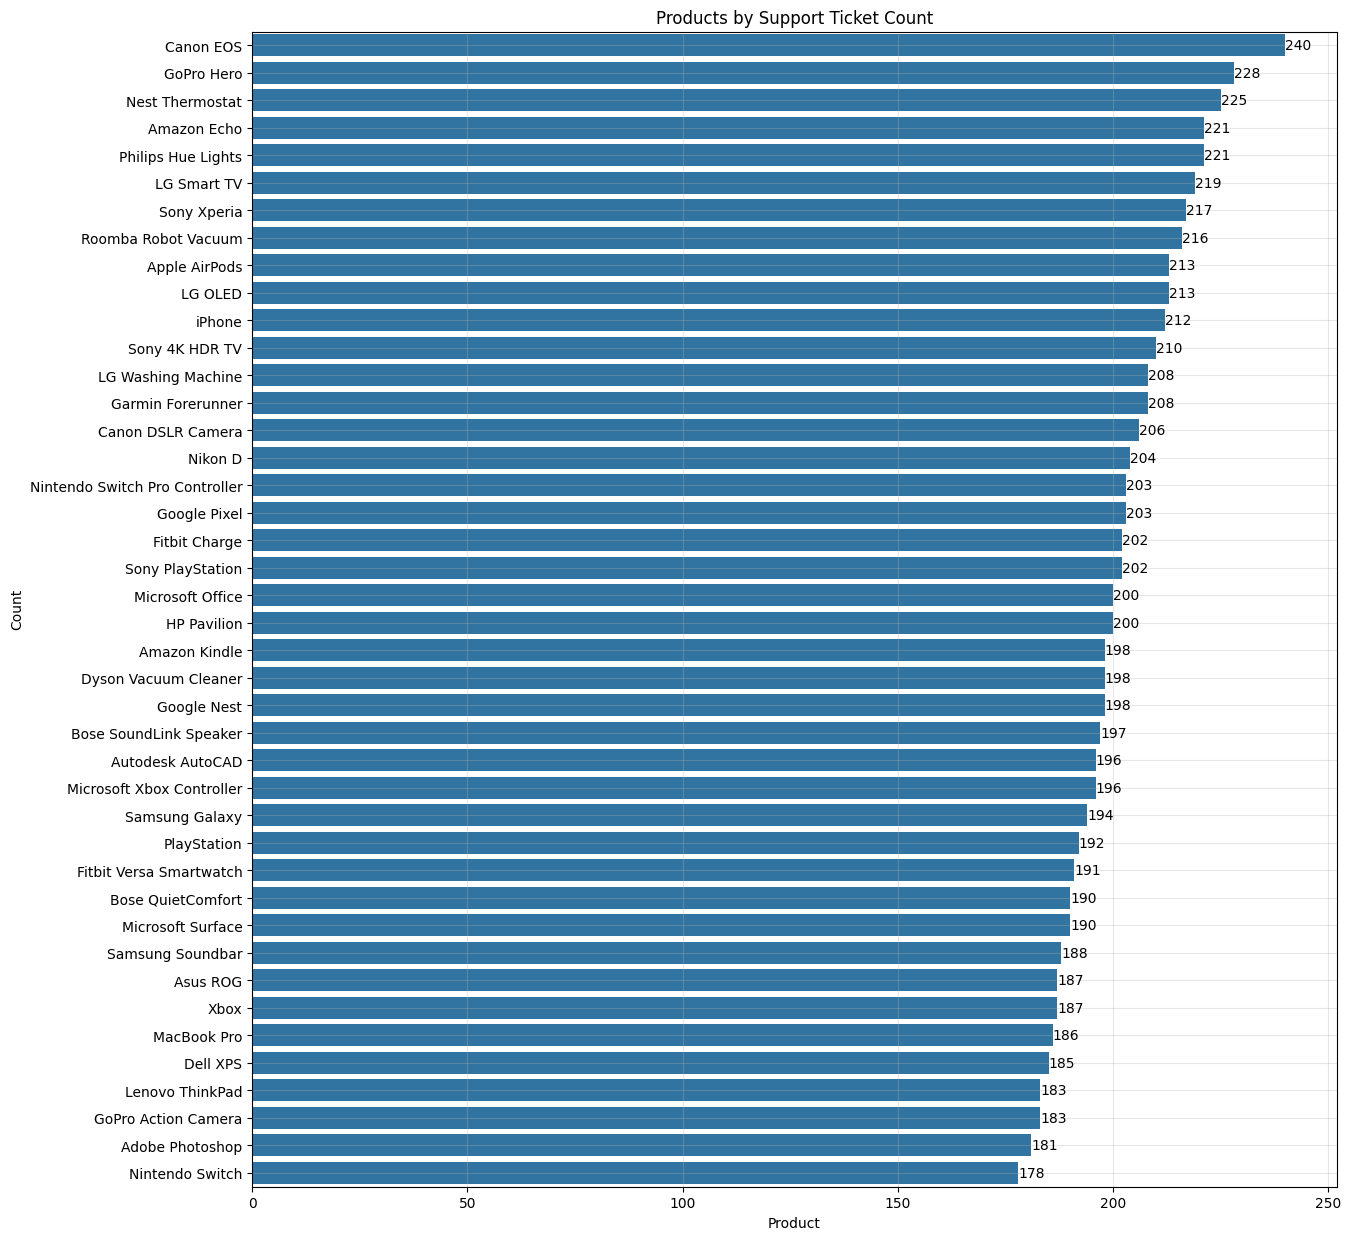

In [134]:
plt.figure(figsize=(14,15))


order = df['product_purchased'].value_counts().index

print(df['product_purchased'].value_counts())
print()

ax = sns.countplot(df['product_purchased'], order=order)

for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Products by Support Ticket Count")
plt.xlabel("Product")
plt.ylabel("Count")

plt.grid(alpha=0.3)
plt.show()

 - Canon EOS generates more tickets meaning Canon EOS has most issues.The company should investigate this product further.

##### 2. What are the top 5 most common customer issues?

ticket_subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64



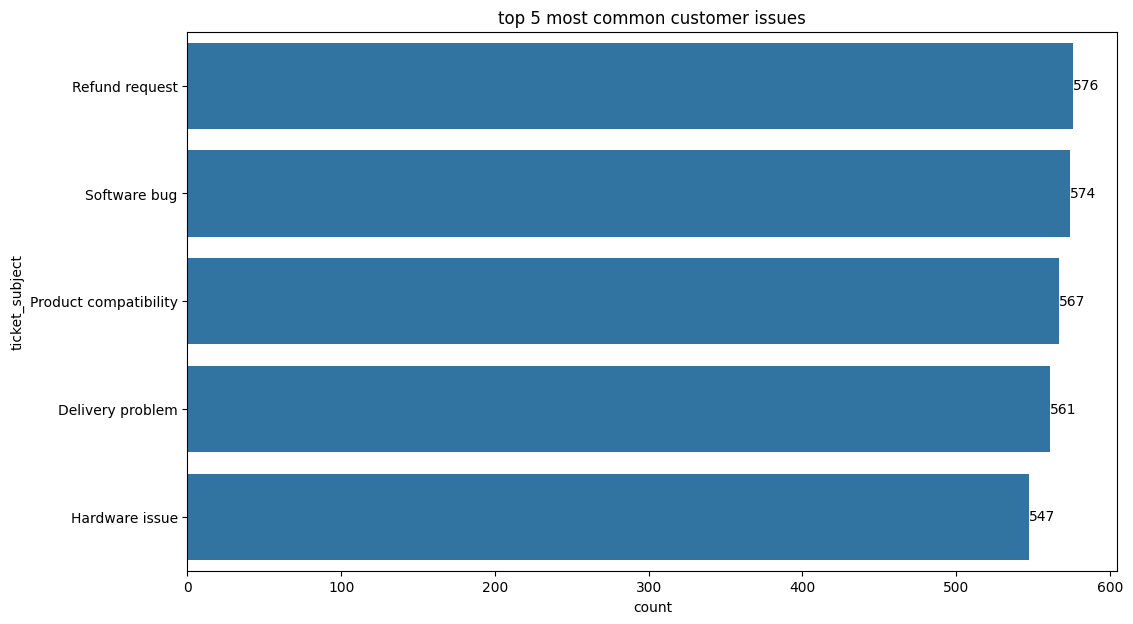

In [133]:
order=df['ticket_subject'].value_counts().head(5).index

print(df['ticket_subject'].value_counts())
print()

plt.figure(figsize=(12,7))
ax=sns.countplot(df['ticket_subject'],order=order)

for bar in ax.containers:
    ax.bar_label(bar)
plt.title("top 5 most common customer issues")
plt.show()

 - most common customer issue is Refund request, followed by software bug.This indicates that a large number of customers are facing problems related to refunds and product/software functionality

##### 3.What percentage of tickets are technical vs non-technical?

In [94]:
ticket_type_df=df['ticket_type'].value_counts().reset_index()

def check(t_type):
    if t_type=='Technical issue':
        return 'Technical'
    else:
        return 'Non Technical'
    
ticket_type_df['technical/non-technical']=ticket_type_df['ticket_type'].apply(check)

ticket_type_df

,ticket_type,count,technical/non-technical
0,Refund request,1752,Non Technical
1,Technical issue,1747,Technical
2,Cancellation request,1695,Non Technical
3,Product inquiry,1641,Non Technical
4,Billing inquiry,1634,Non Technical


  technical/non-technical  count
0           Non Technical   6722
1               Technical   1747



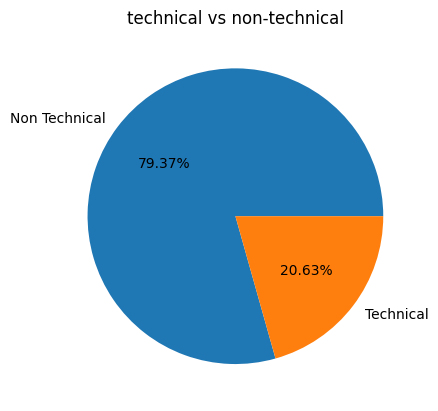

In [132]:
tech_vs_non=ticket_type_df.groupby('technical/non-technical')['count'].sum().reset_index()

print(tech_vs_non)
print()

plt.pie(tech_vs_non['count'],labels=tech_vs_non['technical/non-technical'],autopct='%1.2f%%')
plt.title("technical vs non-technical")
plt.show()

 - Non-technical tickets are higher than technical tickets, indicating that most customer issues are related to business processes such as refunds, billing, and inquiries rather than system or technical problems.

##### 4. Which ticket priorities are most frequent?

  ticket_priority  count
0          Medium   2192
1        Critical   2129
2            High   2085
3             Low   2063



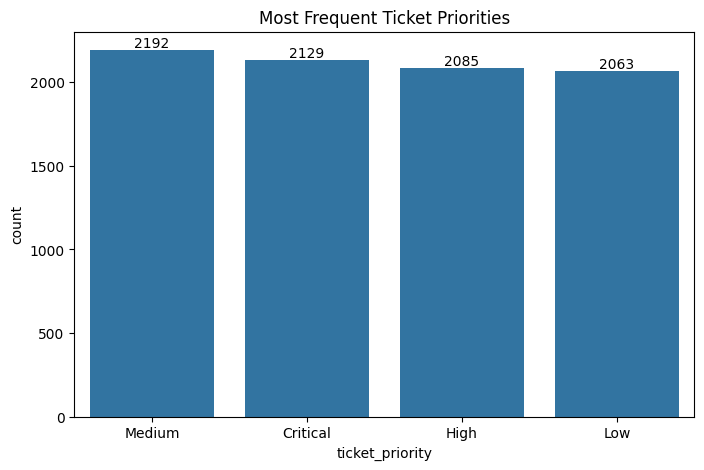

In [131]:
tickets_priority=df['ticket_priority'].value_counts().reset_index()

print(tickets_priority)
print()
plt.figure(figsize=(8,5))
ax=sns.barplot(x=tickets_priority['ticket_priority'],y=tickets_priority['count'])

for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Most Frequent Ticket Priorities")
plt.show()

##### 5.What proportion of tickets remain unresolved?

In [98]:
def not_resolved(status):
    if status=='Closed':
        return 'Resolved'
    else:
        return 'Not Resolved'
    
tickets_unresolved_df=df['ticket_status'].value_counts().reset_index()
tickets_unresolved_df['res/unres']=tickets_unresolved_df['ticket_status'].apply(not_resolved)

tickets_unresolved_df

,ticket_status,count,res/unres
0,Pending,2881,Not Resolved
1,Open,2819,Not Resolved
2,Closed,2769,Resolved


      res/unres  count
0  Not Resolved   5700
1      Resolved   2769



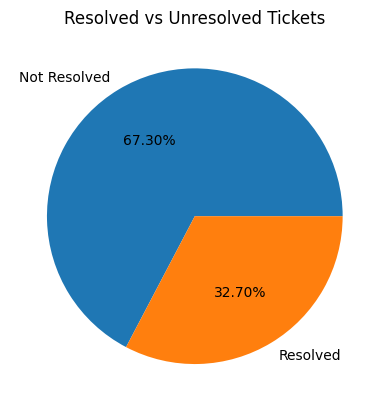

In [130]:
gb1=tickets_unresolved_df.groupby('res/unres')['count'].sum().reset_index()
print(gb1)
print()

plt.pie(gb1['count'],labels=gb1['res/unres'],autopct='%1.2f%%')
plt.title("Resolved vs Unresolved Tickets")
plt.show()

 - Approximately 67.30% of tickets remain unresolved, which is a significant concern for the company.
 - This indicates a large backlog in the support system and may negatively impact customer satisfaction and trust.
 - The company should focus on improving resolution time, optimizing support processes, and prioritizing pending cases to avoid potential long-term consequences.

##### 6. What is the average first response time?

In [100]:
df['response_time']=df['first_response_time']-df['date_of_purchase']


In [101]:
df['response_time'].dt.total_seconds()

0       69250536
1       63996338
2       90933278
3       80378980
4      104803962
          ...   
8464         NaN
8465         NaN
8466    56454262
8467    51301704
8468         NaN
Name: response_time, Length: 8469, dtype: float64

In [102]:
# as response time is like 2 hours 30 minutes,1 day 2 hours this we need to make it like full total hours so for it first we need to convert it into seconds i.e total_seconds() and to convert seconds to hour divide by 3600 becuase 1 hour contains 3600 seconds

df['response_time'].dt.total_seconds() / 3600 #converts seconds to hours



0      19236
1      17777
2      25259
3      22327
4      29112
        ... 
8464     NaN
8465     NaN
8466   15682
8467   14250
8468     NaN
Name: response_time, Length: 8469, dtype: float64

In [103]:
print(f"average response time: {round((df['response_time'].dt.total_seconds() / 3600).mean(),2) } hours")

average response time: 21232.95 hours


##### 7.What is the average time to resolution?

In [104]:
df['resolution_time']=df['time_to_resolution']-df['date_of_purchase']

print(f"average resolution time: {round((df['resolution_time'].dt.total_seconds()/3600).mean())} hours")

average resolution time: 21234 hours


In [105]:
df['resolution_time']=df['resolution_time'].dt.total_seconds()/3600
df['response_time']=df['response_time'].dt.total_seconds()/3600

#in hours

In [106]:
import pandas as pd
pd.set_option('display.float_format', '{:.0f}'.format)

##### 8.Which ticket types take the longest to resolve?

In [107]:
df.groupby('ticket_type')['resolution_time'].mean().reset_index().sort_values(by='resolution_time',ascending=False)

,ticket_type,resolution_time
0,Billing inquiry,21480
2,Product inquiry,21387
3,Refund request,21298
4,Technical issue,21005
1,Cancellation request,21003


 - Refund request tickets have the highest average resolution time, indicating they are more complex or require additional processing compared to other ticket types

##### 9.What percentage of tickets are resolved within SLA (e.g., 24 hrs)?

In [108]:
within_sla = df[df['resolution_time'] <= 24]
within_sla

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,response_time,resolution_time


 - None of the tickets were resolved within the 24-hour SLA, indicating a critical inefficiency in the support process.

##### 10.Which channel (Chat, Email, Social Media) receives most tickets?

ticket_channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64



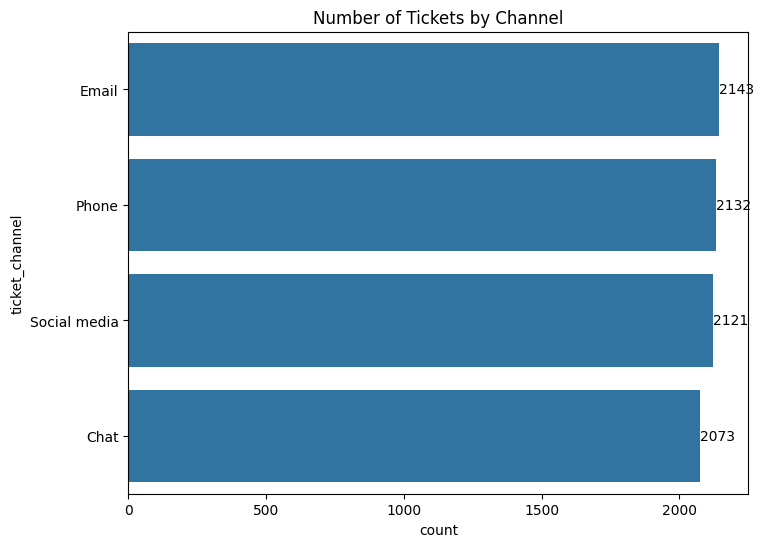

In [129]:
order=df['ticket_channel'].value_counts().index
print(df['ticket_channel'].value_counts())
print()

plt.figure(figsize=(8,6))
ax=sns.countplot(df['ticket_channel'],order=order)
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Number of Tickets by Channel")
plt.show()

 - This indicates that most customers prefer contacting support via **Email**. Phone is the second-most preferred method. Channels like Chat or Social Media are less used.

##### 11.Which channel has the fastest response time?

  ticket_channel  response_time
3   Social media          21056
1          Email          21189
0           Chat          21344
2          Phone          21349



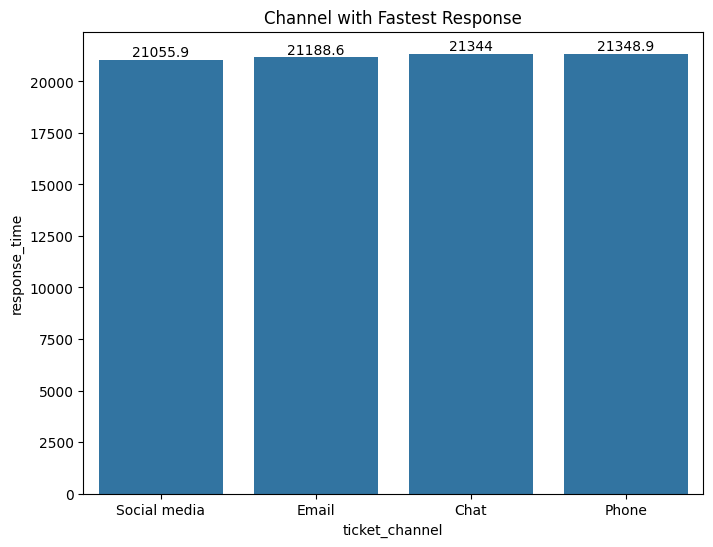

In [128]:
gb2=df.groupby('ticket_channel')['response_time'].mean().reset_index().sort_values(by='response_time')
print(gb2)
print()

plt.figure(figsize=(8,6))
ax=sns.barplot(data=gb2,x=gb2['ticket_channel'],y=gb2['response_time'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Channel with Fastest Response")
plt.show()

 - Social media has fastest response_time than others.This means tickets coming from Social Media are addressed slightly faster than other channels.

##### 12.Which channel has the fastest resolution time?

  ticket_channel  resolution_time
3   Social media            20900
0           Chat            21246
2          Phone            21353
1          Email            21427



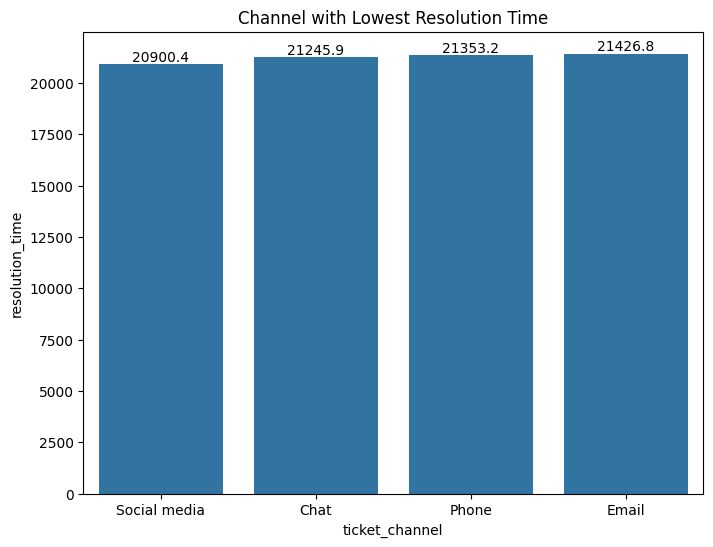

In [127]:
gb3=df.groupby('ticket_channel')['resolution_time'].mean().reset_index().sort_values(by='resolution_time')
print(gb3)
print()

plt.figure(figsize=(8,6))
ax=sns.barplot(data=gb3,x=gb3['ticket_channel'],y=gb3['resolution_time'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Channel with Lowest Resolution Time")
plt.show()

 - social media has fastest resolution time as well as fastest repsonse so company should focus more on other channels tickets too

##### 13.Which channel results in highest customer satisfaction?

In [112]:
df['customer_satisfaction_rating'].unique()

array([nan,  3.,  1.,  4.,  5.,  2.])

In [113]:
df['customer_satisfaction_rating'].dtypes

dtype('float64')

In [116]:
df.groupby('ticket_channel')['customer_satisfaction_rating'].mean().reset_index().sort_values(by='customer_satisfaction_rating')

,ticket_channel,customer_satisfaction_rating
2,Phone,3
1,Email,3
3,Social media,3
0,Chat,3


 - Customer satisfaction is uniform across all support channels, with an average rating of 3. While no channel currently outperforms others, optimizing high-volume channels like Email may yield the greatest benefit to overall customer satisfaction.

##### 14.Which age group raises the most complaints?

In [117]:
def age_group(age):
    if age<12:
        return 'kid'
    elif age<19:
        return 'teenager'
    elif age<39:
        return 'adult'
    elif age<59:
        return 'middle aged'
    else:
        return 'senior citizen'
    

In [118]:
df['age_group']=df['customer_age'].apply(age_group)

        age_group  count
0     middle aged   3224
1           adult   3174
2  senior citizen   1908
3        teenager    163



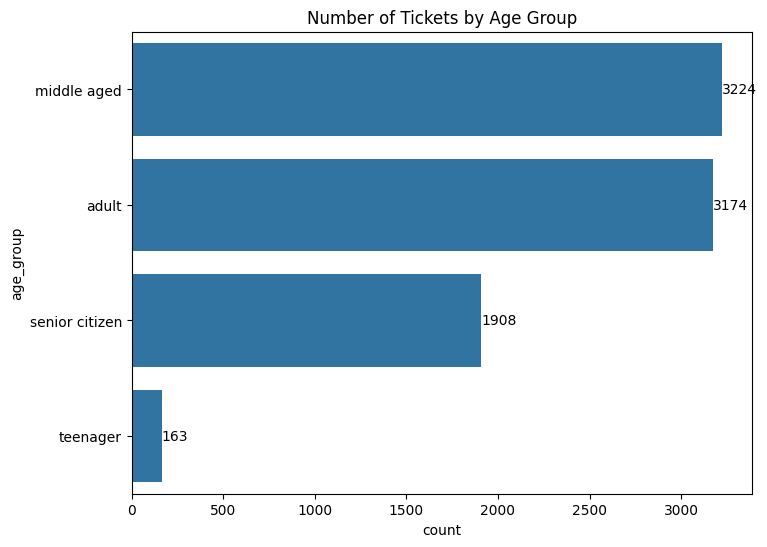

In [126]:
print(df['age_group'].value_counts().reset_index())
print()

gb3=df['age_group'].value_counts().reset_index()
plt.figure(figsize=(8,6))

ax=sns.barplot(data=gb3,x=gb3['count'],y=gb3['age_group'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Number of Tickets by Age Group")
plt.show()

 - middle aged people raise more tickets

##### 15.Do male/female/other customers show different complaint patterns?

In [135]:
df['customer_gender'].value_counts()

customer_gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

   customer_gender           ticket_type  count
0           Female       Billing inquiry    561
1           Female  Cancellation request    557
2           Female       Product inquiry    554
3           Female        Refund request    617
4           Female       Technical issue    598
5             Male       Billing inquiry    560
6             Male  Cancellation request    591
7             Male       Product inquiry    558
8             Male        Refund request    612
9             Male       Technical issue    575
10           Other       Billing inquiry    513
11           Other  Cancellation request    547
12           Other       Product inquiry    529
13           Other        Refund request    523
14           Other       Technical issue    574


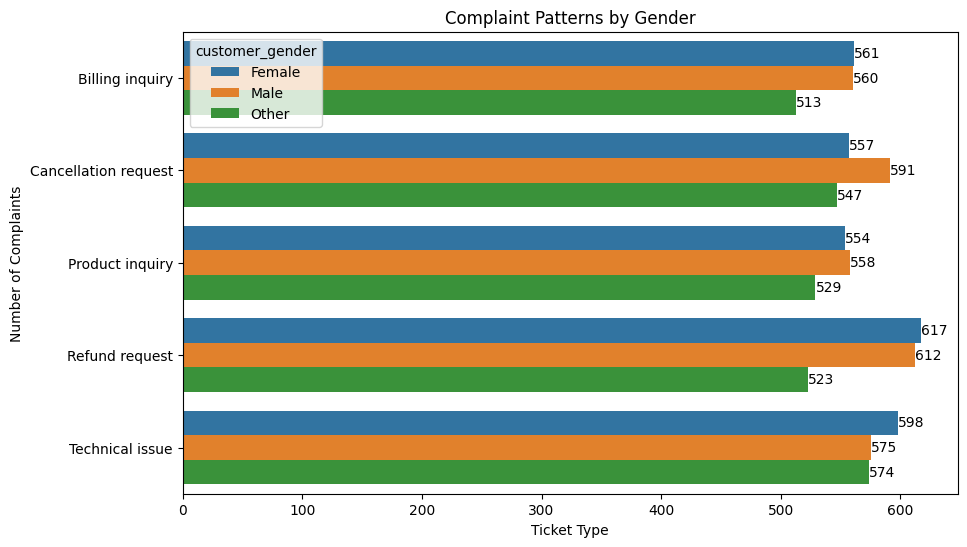

In [141]:

# Group by gender and ticket type to count complaints
gender_ticket = df.groupby(['customer_gender', 'ticket_type']).size().reset_index(name='count')

# Display the table
print(gender_ticket)


plt.figure(figsize=(10,6))
ax=sns.barplot(data=gender_ticket, y='ticket_type', x='count', hue='customer_gender')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Complaint Patterns by Gender")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Complaints")

plt.show()

 - Complaint handling and support resources should be balanced across genders, as male and female customers show similar patterns. Special attention could be given to refund and cancellation requests, as these are slightly higher for females and males respectively, while the ‘Other’ category has fewer tickets but should still be monitored.

##### 16.Which products have the most critical issues?

In [150]:
# Filter critical tickets
critical_tickets = df[df['ticket_priority'] == 'Critical']

# Group by product and count number of critical tickets per product
critical_per_product = critical_tickets.groupby('product_purchased').size().reset_index(name='Critical Issues Count')

# Sort descending
critical_per_product = critical_per_product.sort_values(by='Critical Issues Count', ascending=False)

print(critical_per_product)

                 product_purchased  Critical Issues Count
9                        Canon EOS                     67
18                    Google Pixel                     65
16                      GoPro Hero                     64
28                 Nest Thermostat                     62
8                Canon DSLR Camera                     62
34             Roomba Robot Vacuum                     60
5                 Autodesk AutoCAD                     59
21                     LG Smart TV                     59
39                     Sony Xperia                     58
11            Dyson Vacuum Cleaner                     58
41                          iPhone                     57
22              LG Washing Machine                     57
20                         LG OLED                     56
13         Fitbit Versa Smartwatch                     55
1                      Amazon Echo                     54
32              Philips Hue Lights                     53
10            

 - Canon EOS have most critical issues

##### 17.Which products take the longest to resolve issues?

                 product_purchased  resolution_time
13         Fitbit Versa Smartwatch            22417
12                   Fitbit Charge            22254
5                 Autodesk AutoCAD            22252
40                            Xbox            21863
9                        Canon EOS            21655
16                      GoPro Hero            21606
20                         LG OLED            21587
4                         Asus ROG            21540
7           Bose SoundLink Speaker            21531
24                     MacBook Pro            21501
41                          iPhone            21484
37                  Sony 4K HDR TV            21478
23                 Lenovo ThinkPad            21441
1                      Amazon Echo            21428
10                        Dell XPS            21412
2                    Amazon Kindle            21383
39                     Sony Xperia            21307
34             Roomba Robot Vacuum            21304
29          

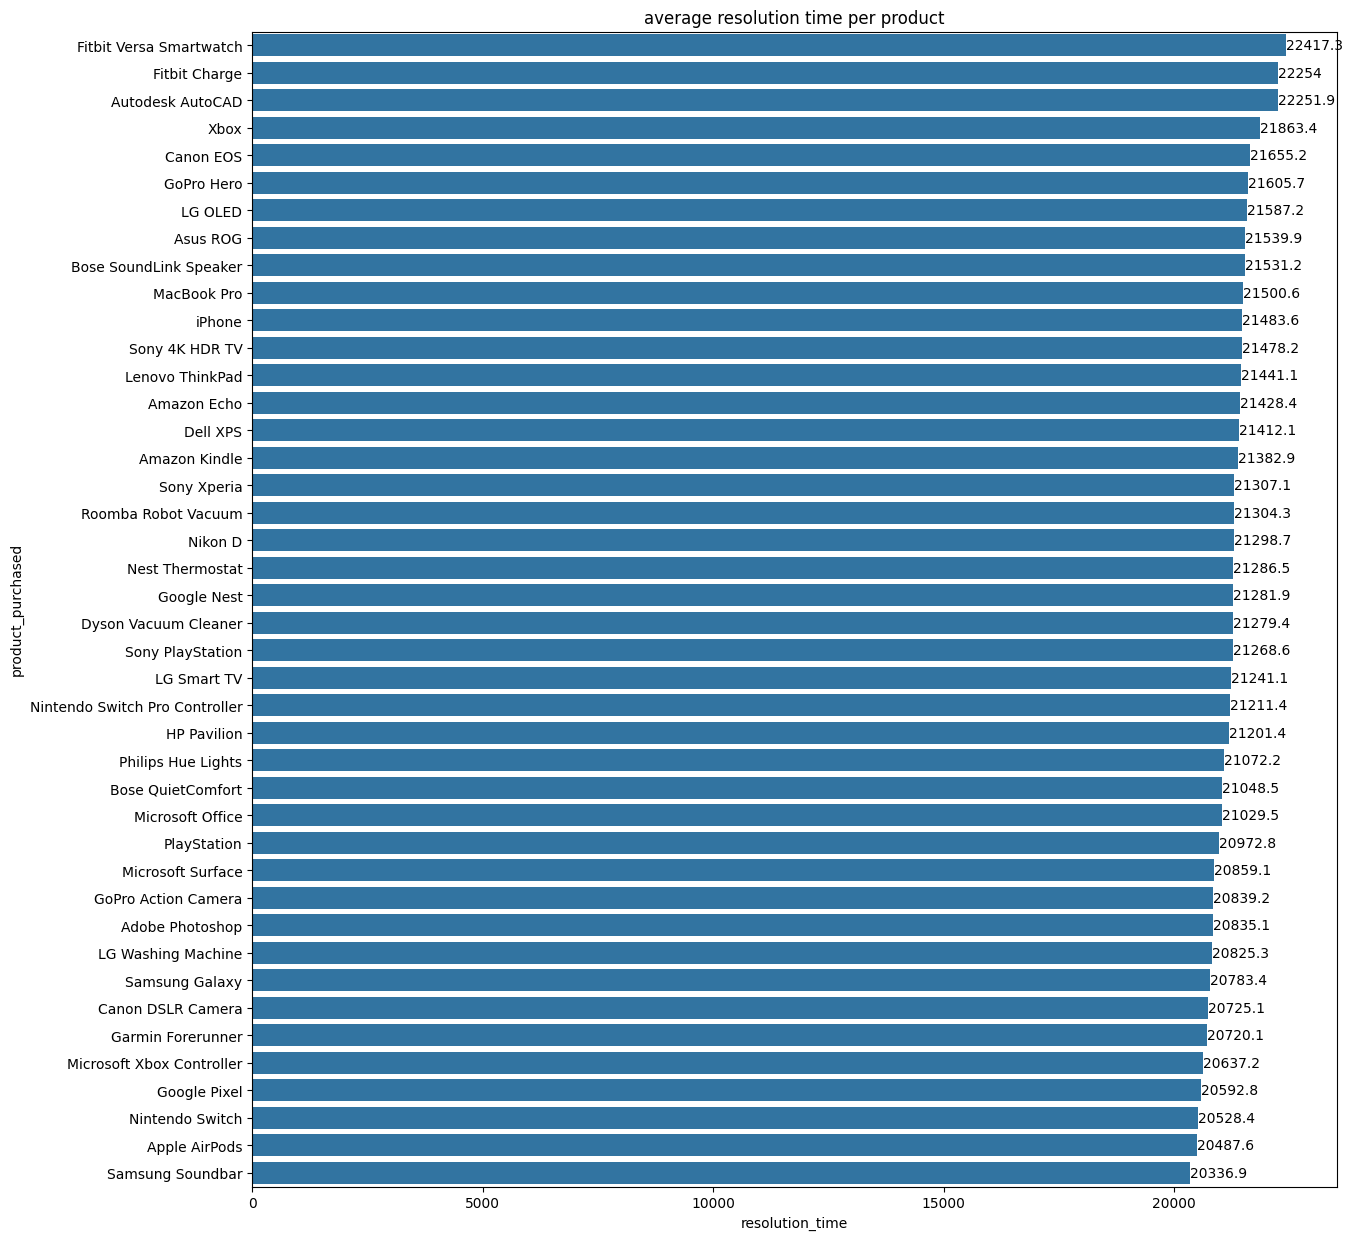

In [157]:
gb4=df.groupby('product_purchased')['resolution_time'].mean().reset_index().sort_values(by='resolution_time',ascending=False)

print(gb4)
print()

plt.figure(figsize=(14,15))

ax=sns.barplot(data=gb4,x=gb4['resolution_time'],y=gb4['product_purchased'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("average resolution time per product")
plt.show()

 - Fitbit Versa Smartwatch            22417 take longest time to resolve

##### 18.Which products receive the lowest satisfaction ratings?

In [162]:
df.groupby('product_purchased')['customer_satisfaction_rating'].mean().reset_index().sort_values(by='customer_satisfaction_rating')

,product_purchased,customer_satisfaction_rating
13,Fitbit Versa Smartwatch,3
39,Sony Xperia,3
15,GoPro Action Camera,3
10,Dell XPS,3
20,LG OLED,3
27,Microsoft Xbox Controller,3
3,Apple AirPods,3
6,Bose QuietComfort,3
30,Nintendo Switch,3
33,PlayStation,3


 - All products have the same customer satisfaction rating of 3, so there are no products with lower satisfaction than others.

##### 19.How does ticket volume change over months/years?

In [165]:
df['year'] = df['date_of_purchase'].dt.year
df['month'] = df['date_of_purchase'].dt.month

# Group by year and month to count tickets
ticket_volume = df.groupby(['year', 'month']).size().reset_index(name='Ticket Count')

# Optional: sort by year and month
ticket_volume = ticket_volume.sort_values(by=['year', 'month'])

print(ticket_volume)

    year  month  Ticket Count
0   2020      1           377
1   2020      2           376
2   2020      3           324
3   2020      4           354
4   2020      5           322
5   2020      6           358
6   2020      7           366
7   2020      8           327
8   2020      9           369
9   2020     10           373
10  2020     11           340
11  2020     12           350
12  2021      1           359
13  2021      2           339
14  2021      3           348
15  2021      4           364
16  2021      5           379
17  2021      6           320
18  2021      7           361
19  2021      8           364
20  2021      9           327
21  2021     10           362
22  2021     11           364
23  2021     12           346


##### 20.Are complaints increasing or decreasing?

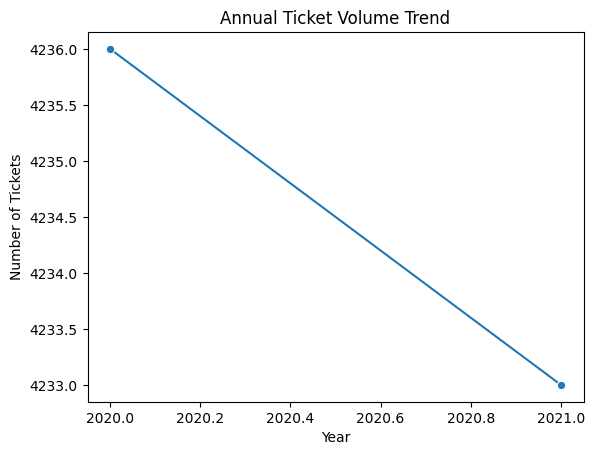

In [179]:
sns.lineplot(df.groupby('year').size(),marker='o')
plt.title("Annual Ticket Volume Trend")  
plt.xlabel("Year")
plt.ylabel("Number of Tickets")
plt.show()

 - the tickets count is clearly decreasing 

##### 21.Are response times improving over time?

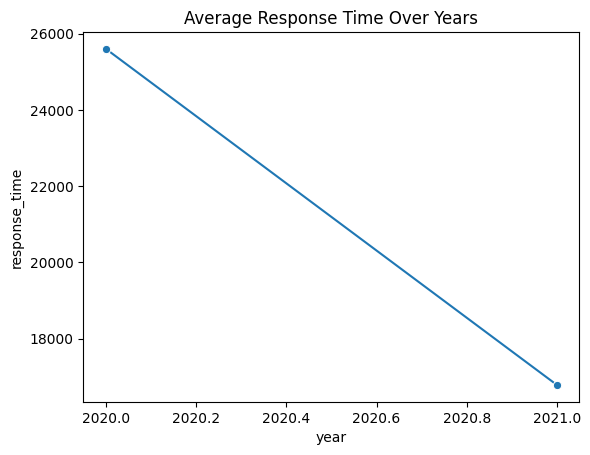

In [178]:
sns.lineplot(df.groupby('year')['response_time'].mean(),marker='o')
plt.title("Average Response Time Over Years")
plt.show()

 - The company is improving its response efficiency, which is a positive sign for customer service.

##### 22.Are resolution times improving?

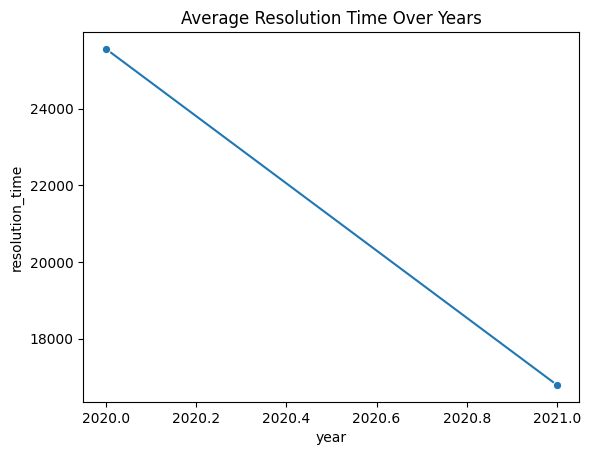

In [181]:
sns.lineplot(df.groupby('year')['resolution_time'].mean(),marker='o')
plt.title("Average Resolution Time Over Years")
plt.show()

 - resolution time is also decreasing over time

##### 23.Does faster response time lead to higher satisfaction?

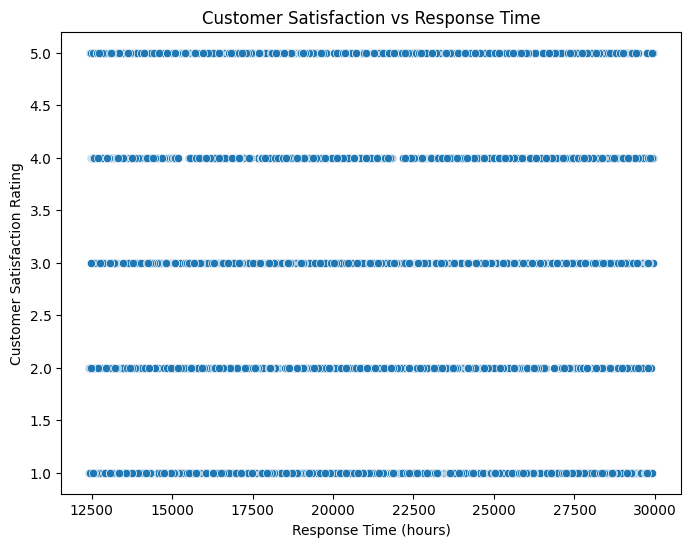

In [182]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='response_time', y='customer_satisfaction_rating')
plt.title('Customer Satisfaction vs Response Time')
plt.xlabel('Response Time (hours)')
plt.ylabel('Customer Satisfaction Rating')
plt.show()

- 8,469 total tickets across 2020–2021
- 67.3% tickets unresolved — major backlog problem
- 0% SLA compliance — no ticket resolved within 24 hours
- Canon EOS = most tickets & most critical issues
- Fitbit Versa = longest resolution time (~22,417 hrs)
- Refund requests = #1 complaint type
- 79% tickets are non-technical (refunds, billing, cancellations)
- All channels & products rated 3/5 — uniformly average satisfaction
- Middle-aged customers raise the most tickets
- Email is the most used channel; Social Media is the fastest
- Ticket volume decreasing year-over-year 
- Response & resolution times improving year-over-year 

In [166]:
df.head(2)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,response_time,resolution_time,age_group,year,month
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,19236,NaN,adult,2021,3
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,17777,NaN,middle aged,2021,5
